In [1]:
# Checking torch and torchvision version 
import torch 
import torchvision 

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


#### 1. Importing necessary libraries 

In [2]:
import torch 
import torchvision
import matplotlib.pyplot as plt 
from torch import nn
from torchvision import transforms

# try importing summary from torchinfo 
try: 
    from torchinfo import summary 
except: 
    print("['INFO'] couldn't find ... Downloading it.")
    !pip install -q torchinfo 
    from torchinfo import summary 
    
# try importing our 05_going_modular scripts 
try: 
    from going_modular.going_modular import data_setup, engine 
except: 
    print("\nCouldn't find going_modular ... Downloading from github")
    !git clone "https://github.com/Abisheklimbu/pytorch.git"
    !mv pytorch/going_modular . 
    !rm -rf pytorch
    from  going_modular.going_modular import data_setup, engine 
    

['INFO'] couldn't find ... Downloading it.

Couldn't find going_modular ... Downloading from github
Cloning into 'pytorch'...
remote: Enumerating objects: 2251, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 2251 (delta 6), reused 10 (delta 4), pack-reused 2231 (from 3)
Receiving objects: 100% (2251/2251), 268.97 MiB | 38.22 MiB/s, done.
Resolving deltas: 100% (188/188), done.
Updating files: 100% (2468/2468), done.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

#### 2. Get Data

In [4]:
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/Abisheklimbu/pytorch/raw/main/data_creation/data/pizza_steak_sushi.zip")
        
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [5]:
train_dir = image_path/"train"
test_dir = image_path/"test"

In [6]:
print(f"Total training image: {len(list(Path(train_dir).glob("*/*.jpg")))}")
print(f"Total testing image: {len(list(Path(test_dir).glob("*/*.jpg")))}")

Total training image: 1350
Total testing image: 450


#### 3. Create dataset and dataloaders 

In [7]:
# manual_transforms 
manual_transforms = torchvision.transforms.Compose([
    transforms.Resize((224,224)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean= [0.485, 0.456, 0.406], 
                        std= [0.229, 0.224, 0.225])
])
manual_transforms

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [8]:
# auto_transforms
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [9]:
train_dataloader, test_dataloader, num_classes = data_setup.create_dataloaders(train_dir=train_dir, 
                                                                              test_dir=test_dir, 
                                                                              transform=auto_transforms, 
                                                                              batch_size=32)

In [10]:
train_dataloader, test_dataloader, num_classes

(<torch.utils.data.dataloader.DataLoader at 0x7daa0338be90>,
 ['pizza', 'steak', 'sushi'])

#### 4. Load pre-trained models 

In [11]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT 
model = torchvision.models.efficientnet_b0(weights=weights).to(device)
model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 107MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### 5. Let's look at the summary and freeze features layers 

In [12]:
summary(model= model, 
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"], 
        col_width= 20,
        row_settings= ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [13]:
# freeze features layers
for param in model.features.parameters():
    param.requires_grad= False

torch.manual_seed(42)
torch.cuda.manual_seed(42)
model.classifier = nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, 
                   out_features=len(num_classes), 
                   bias=True).to(device)
)

In [14]:
# let's again print summary
summary(model=model, 
        input_size=(32,3,224,224), 
        verbose=0, 
        col_names=["input_size", "output_size", "num_params", "trainable"], 
        col_width=20, 
        row_settings=["var_names"]
       )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

#### 6. Train model 

In [15]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from timeit import default_timer as timer

start_timer = timer()
results = engine.train(model=model, 
                      train_dataloader=train_dataloader, 
                      test_dataloader=test_dataloader, 
                      loss_fn=loss_fn, 
                      optimizer=optimizer,
                      epochs=5, 
                      device=device)
end_timer = timer()
print(f"Total training time {end_timer-start_timer:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7568 | train_acc: 0.7318 | test_loss: 0.4160 | test_acc: 0.9187
Epoch: 2 | train_loss: 0.4583 | train_acc: 0.8643 | test_loss: 0.2940 | test_acc: 0.9354
Epoch: 3 | train_loss: 0.3784 | train_acc: 0.8786 | test_loss: 0.2416 | test_acc: 0.9313
Epoch: 4 | train_loss: 0.3434 | train_acc: 0.8854 | test_loss: 0.2234 | test_acc: 0.9333
Epoch: 5 | train_loss: 0.3078 | train_acc: 0.9046 | test_loss: 0.2117 | test_acc: 0.9375
Total training time 73.672 seconds


In [17]:
results

{'train_loss': [0.7567935613698737,
  0.4583348659581916,
  0.37841890786969384,
  0.3434059210987978,
  0.30775003585704536],
 'train_acc': [0.7318313953488372,
  0.8643410852713178,
  0.8786337209302325,
  0.8854166666666666,
  0.9045542635658915],
 'test_loss': [0.41604549884796144,
  0.2939756949742635,
  0.24158269216616948,
  0.22340417404969534,
  0.21171776652336122],
 'test_acc': [0.91875,
  0.9354166666666667,
  0.93125,
  0.9333333333333333,
  0.9375]}

#### 7. Evaluate model by plotting loss and accuracy 

In [18]:
try: 
    from helper_function import plot_loss_curves

except: 
    print("Couldn't find. Downloading ...")
    with open("helper_function.py", "wb") as file:
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        file.write(request.content)
    from helper_function import plot_loss_curves 

Couldn't find. Downloading ...


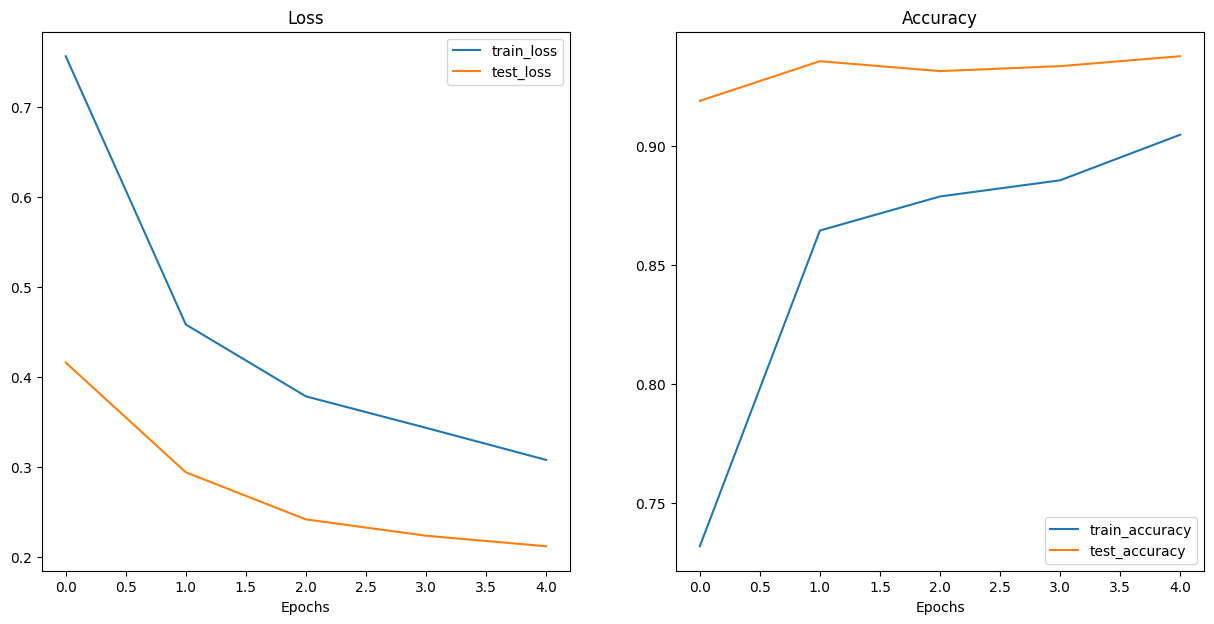

In [19]:
plot_loss_curves(results)

In [20]:
def plot_loss_curve(results): 
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]

    train_acc = results["train_acc"]
    test_acc = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, test_acc, label="test_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

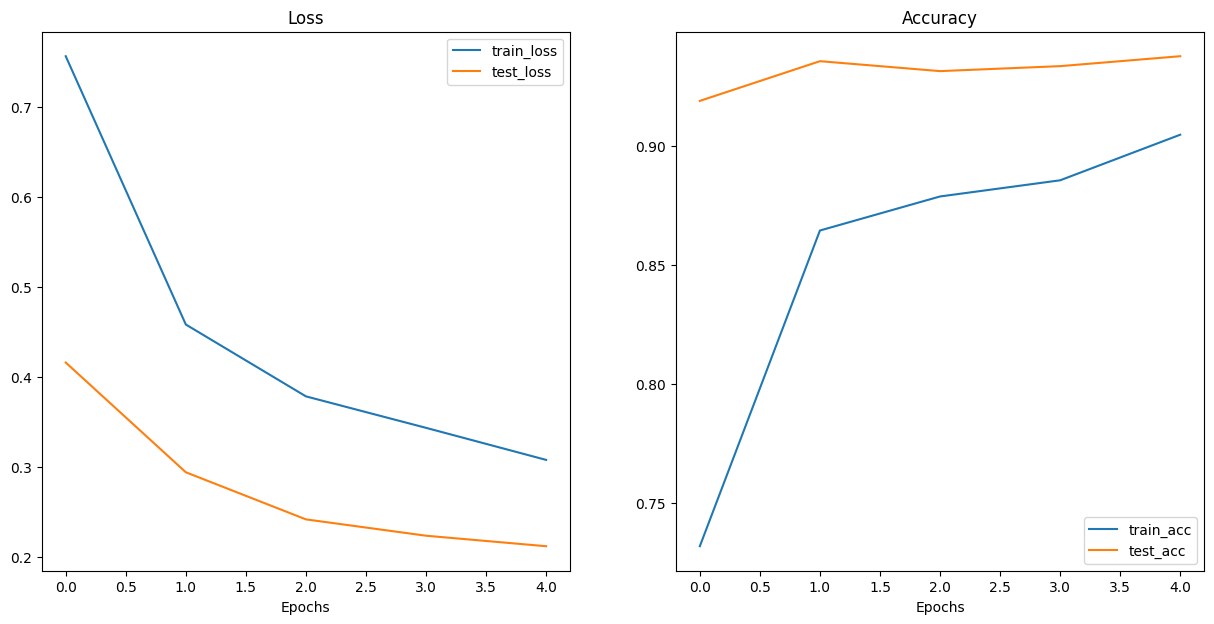

In [21]:
plot_loss_curve(results)

#### 8. Predict and plot test images

In [22]:
from typing import List, Tuple 
from torchvision import transforms 
from PIL import Image 

def pred_and_plot(model:torch.nn.Module, 
                  image_path:str, 
                  class_names:List[str], 
                  image_size:Tuple[int, int]=(224,224),
                  transform:torchvision.transforms = None, 
                  device:torch.device = device):
    
    # load image 
    image = Image.open(image_path)
    
    # create transforms
    if transform is not None: 
        image_transform = transform 
    else:
        image_transform = torchvision.transforms.Compose([
            transforms.Resize((224,224)), 
            transforms.ToTensor(), 
            transforms.Normalize(mean= [0.485, 0.456, 0.406], 
                                 std= [0.229, 0.224, 0.225])
            ])
    
    # model to device 
    model.to(device)
    
    # eval 
    model.eval()
    with torch.inference_mode():
        transformed_image = image_transform(image).unsqueeze(dim=0)
        target_img_pred = model(transformed_image.to(device))
        
    target_img_pred_probs = torch.softmax(target_img_pred, dim=1)
    target_img_pred_label = torch.argmax(target_img_pred_probs, dim=1)
    
    plt.figure()
    plt.imshow(image)
    plt.title(f"Pred: {class_names[target_img_pred_label]} | prob: {target_img_pred_probs.max():.2f}")
    plt.axis("off")

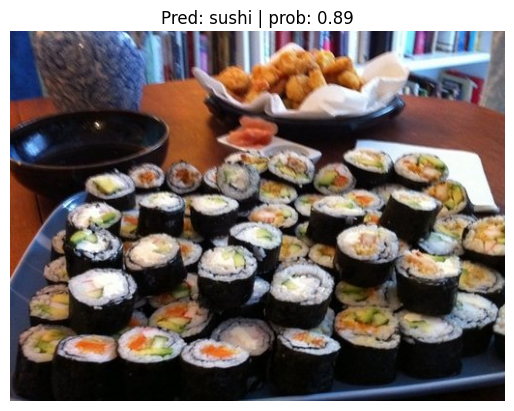

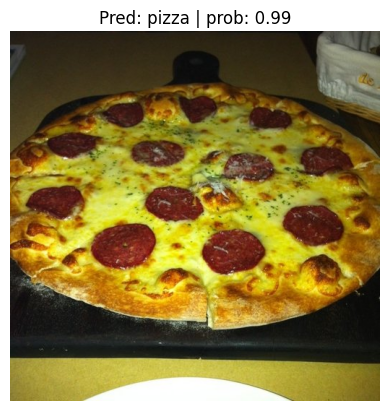

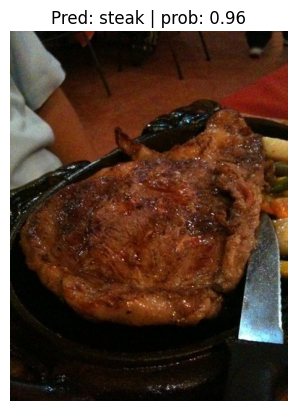

In [23]:
import random
num_img_to_plot = 3 
test_image_path = list(Path(test_dir).glob("*/*.jpg"))
test_image_random_sample = random.sample(population=test_image_path, 
                                         k=num_img_to_plot)

for image_path in test_image_random_sample:
    pred_and_plot(model=model, 
                  image_path=image_path, 
                  class_names=num_classes,
                  )

#### 9. Predict and plot on cutsom image

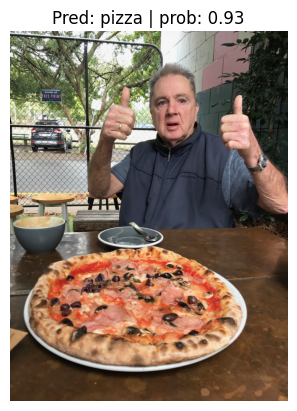

In [24]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot(model=model,
                    image_path=custom_image_path,
                    class_names=num_classes)